# Plot Fitted Curves for a Single Pixel

This notebook extracts a time-series from a specific pixel, and plots the fitted curves from NuFrost, Zhu2015, and HANTS.

In [101]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CACHE_DIR = PROJECT_DIR / "data" / "cache"
DATA_DIR = PROJECT_DIR / "data" / "input"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"[Info] Project directory: {PROJECT_DIR}")
print(f"[Info] Cache directory: {CACHE_DIR}")
print(f"[Info] Data directory: {DATA_DIR}")

print(f"[Info] Changing working directory to: {PROJECT_DIR}")
os.chdir(str(PROJECT_DIR))

[Info] Project directory: /Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost
[Info] Cache directory: /Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost/data/cache
[Info] Data directory: /Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost/data/input
[Info] Changing working directory to: /Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost


In [102]:
import importlib
from config import build_args
from src.data_loader import RSCube
from src.nufrost import timestamps_to_seconds, predict_curve_pixel as predict_curve_nufrost
from src.zhu2015 import predict_curve_pixel as predict_curve_zhu2015
from src.hants import hants_curve_pixel
import src.nufrost
import src.zhu2015
import src.hants

importlib.reload(src.nufrost)
importlib.reload(src.zhu2015)
importlib.reload(src.hants)

<module 'src.hants' from '/Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost/src/hants.py'>

## Configuration

Specify the image name below. Also specify `TARGET_ROW` and `TARGET_COL` to pick a pixel. If you leave them as `None`, the center pixel will be used.

In [103]:
# --- Configuration ---
IMAGE_FILENAME = "COPERNICUS_S2_HARMONIZED_B2_lon94.2605_lat29.7733.tif"

# Set coordinate (row, col) e.g., (100, 100). Set to None to use the image center.
TARGET_ROW = None
TARGET_COL = None
# ---------------------

IMAGE_PATH = DATA_DIR / IMAGE_FILENAME
if not IMAGE_PATH.exists():
    print(f"[Error] File not found: {IMAGE_PATH}")
else:
    print(f"[Info] Target image: {IMAGE_PATH}")

[Info] Target image: /Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost/data/input/COPERNICUS_S2_HARMONIZED_B2_lon94.2605_lat29.7733.tif


In [104]:
# Load the data
loader = RSCube(str(IMAGE_PATH), cache_dir=str(CACHE_DIR))
data = loader.load()
cube = data["cube"]
timestamps = data["timestamps"]

T, H, W = cube.shape

if TARGET_ROW is None:
    r = H // 2
else:
    r = TARGET_ROW

if TARGET_COL is None:
    c = W // 2
else:
    c = TARGET_COL

print(f"[Info] Selected Pixel: (Row={r}, Col={c}) out of (H={H}, W={W})")

y_ts = cube[:, r, c]
t_sec = timestamps_to_seconds(timestamps, unit="seconds")
t0_sec = np.min(t_sec)
t_days = (t_sec - t0_sec) / 86400.0

# Prepare target times for plotting a smooth curve (e.g. 1 point per day)
days_range = int(np.ceil(np.max(t_days)))
target_t_days = np.linspace(0, days_range, days_range * 2) # Every 0.5 days
target_t_secs = target_t_days * 86400.0 + t0_sec
target_dates = [pd.Timestamp(t, unit="s") for t in target_t_secs]
original_dates = [pd.Timestamp(t, unit="s") for t in t_sec]

print(f"[Info] Original observations: {len(y_ts)} (Valid: {np.sum(np.isfinite(y_ts))})")
print(f"[Info] Target points for curve: {len(target_t_days)}")

[System] Loading from cache: /Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost/data/cache/COPERNICUS_S2_HARMONIZED_B2_lon94.2605_lat29.7733_d9f14866e21c.npz
[Info] Selected Pixel: (Row=513, Col=587) out of (H=1027, W=1175)
[Info] Original observations: 169 (Valid: 127)
[Info] Target points for curve: 7430


In [105]:
# Load standard algorithm args
args = build_args({})

print("Predicting NuFrost curve...")
pred_nufrost = predict_curve_nufrost(
    t_sec, y_ts, target_t_secs,
    nufft_modes=args.modes, eps=args.eps,
    num_peaks=args.num_peaks, power_cum=args.power_cum, ignore_dc_hz=args.ignore_dc_hz,
    refine_peaks=args.refine_peaks, include_trend=args.include_trend,
    ridge_lam=args.ridge, freq_weight=args.freq_weight, huber_iters=args.huber_iters, huber_delta=args.huber_delta,
    min_obs=args.min_obs
)

print("Predicting Zhu2015 curve...")
pred_zhu2015 = predict_curve_zhu2015(t_days, y_ts, target_t_days, lasso_alpha=0.0001)

print("Predicting HANTS curve...")
pred_hants = hants_curve_pixel(t_days, y_ts, target_t_days, nof=3, sf='low', fet=0.05, dod=5)

print("Done!")

Predicting NuFrost curve...
Predicting Zhu2015 curve...


/opt/homebrew/Caskroom/miniforge/base/envs/geo-science/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.464e+03, tolerance: 4.032e+00
  model = cd_fast.enet_coordinate_descent(
/opt/homebrew/Caskroom/miniforge/base/envs/geo-science/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.908e+03, tolerance: 7.719e+00
  model = cd_fast.enet_coordinate_descent(
/opt/homebrew/Caskroom/miniforge/base/envs/geo-science/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the nu

Predicting HANTS curve...
Done!


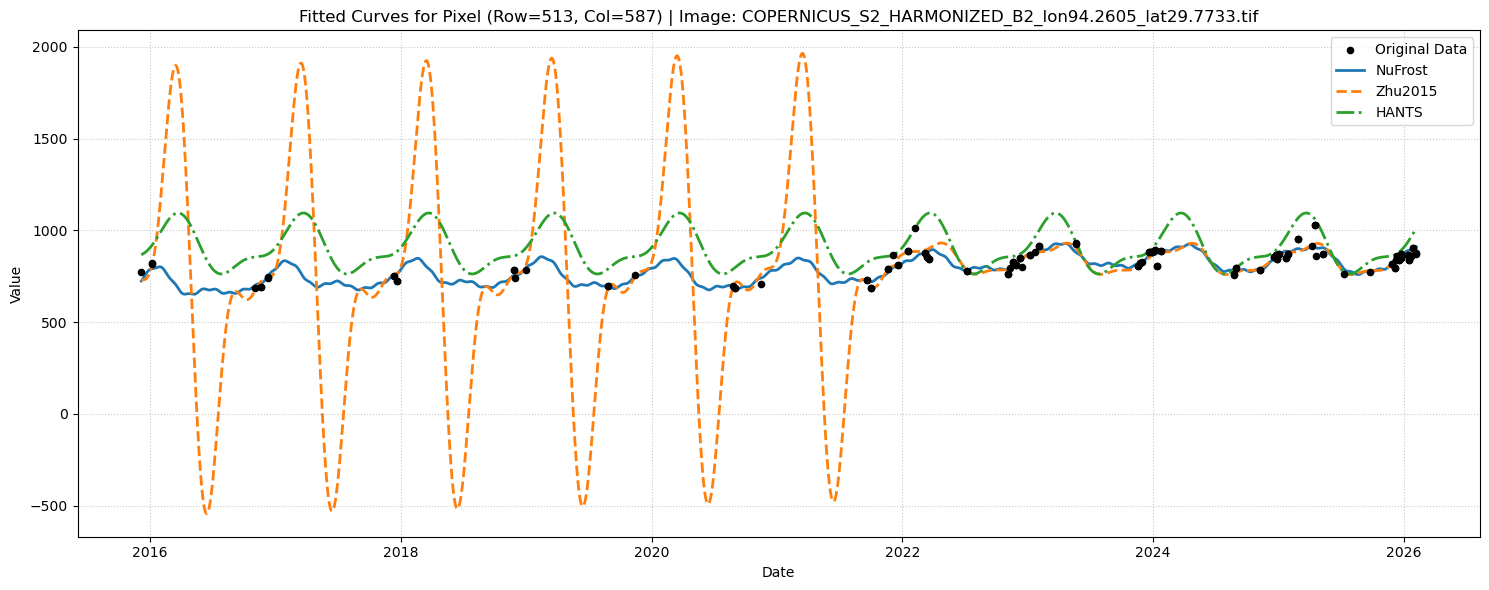

In [106]:
plt.figure(figsize=(15, 6))
plt.scatter(original_dates, y_ts, color='black', label='Original Data', zorder=5, s=20)

plt.plot(target_dates, pred_nufrost, label='NuFrost', linewidth=2, color='tab:blue')
plt.plot(target_dates, pred_zhu2015, label='Zhu2015', linewidth=2, color='tab:orange', linestyle='--')
plt.plot(target_dates, pred_hants, label='HANTS', linewidth=2, color='tab:green', linestyle='-.')

plt.title(f"Fitted Curves for Pixel (Row={r}, Col={c}) | Image: {IMAGE_FILENAME}")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()